Image exists: True
Resolved path: C:\Users\aksha\Documents\lingomatch_poc\data\inputs\test_arabic_01.png
Image size: (1822, 479)


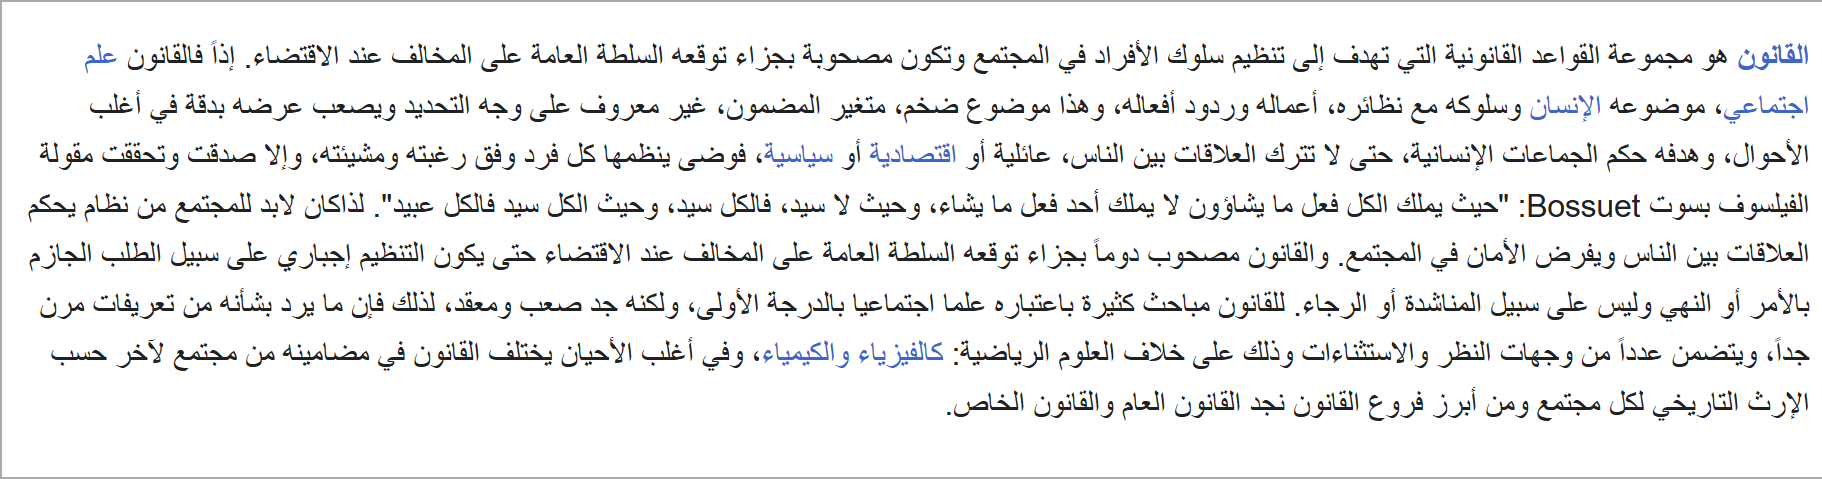

In [1]:
from PIL import Image
from pathlib import Path

image_path = Path("../data/inputs/test_arabic_01.png")
print(f"Image exists: {image_path.exists()}")
print(f"Resolved path: {image_path.resolve()}")

image = Image.open(image_path)
print(f"Image size: {image.size}")
image

In [2]:
from surya.foundation import FoundationPredictor
from surya.recognition import RecognitionPredictor
from surya.detection import DetectionPredictor

# Load Surya's two main components
foundation_predictor = FoundationPredictor()
recognition_predictor = RecognitionPredictor(foundation_predictor)
detection_predictor = DetectionPredictor()

print("Surya loaded.")

Surya loaded.


In [3]:
# Surya wants a list of images and a list of language codes per image
predictions = recognition_predictor(
    [image],           # list with one image
    det_predictor=detection_predictor,
)

# Predictions is a list (one entry per input image)
result = predictions[0]
print(f"Number of text lines detected: {len(result.text_lines)}")
print()

for i, line in enumerate(result.text_lines, 1):
    print(f"Line {i}: {line.text}")
    print(f"  Confidence: {line.confidence:.3f}")
    print()

Recognizing Text: 100%|██████████████████████████████████████████████████████████████████| 8/8 [00:07<00:00,  1.04it/s]


Number of text lines detected: 8

Line 1: القانون هو مجموعة القواعد القانونية التي تهدف إلى تنظيم سلوك الأفراد في المجتمع وتكون مصحوبة بجزاء توقعه السلطة العامة على المخالف عند الاقتضاء. إذاً فالقانون علم
  Confidence: 0.989

Line 2: اجتماعي، موضوعه الإنسان وسلوكه مع نظائره، أعماله وردود أفعاله، وهذا موضوع ضخم، متغير المضمون، غير معروف على وجه التحديد ويصعب عرضه بدقة في أغلب
  Confidence: 0.996

Line 3: الأحوال، وهدفه حكم الجماعات الإنسانية، حتى لا تترك العلاقات بين الناس، عائلية أو اقتصادية أو سياسية، فوضى ينظمها كل فرد وفق رغبته ومشيئته، وإلا صدقت وتحققت مقولة
  Confidence: 0.993

Line 4: الفيلسوف بسوت Bossuet: "حيث يملك الكل فعل ما يشاؤون لا يملك أحد فعل ما يشاء، وحيث لا سيد، فالكل سيد، وحيث الكل سيد فالكل عبيد". لذاكان لابد للمجتمع من نظام يحكم
  Confidence: 0.999

Line 5: العلاقات بين الناس ويفرض الأمان في المجتمع. والقانون مصحوب دوماً بجزاء توقعه السلطة العامة على المخالف عند الاقتضاء حتى يكون التنظيم إجباري على سبيل الطلب الجازم
  Confidence: 0.995

Line 6: بالأمر أو النهي وليس 

In [4]:
import time
start = time.time()
predictions = recognition_predictor([image], det_predictor=detection_predictor)
elapsed = time.time() - start
print(f"OCR took {elapsed:.2f} seconds.")

Recognizing Text: 100%|██████████████████████████████████████████████████████████████████| 8/8 [00:10<00:00,  1.31s/it]

OCR took 10.85 seconds.
